# BÁO CÁO BÀI TẬP LỚN: HỒI QUY LOGISTIC (LOGISTIC REGRESSION)
## BÀI TOÁN PHÂN LOẠI NHỊ PHÂN: DỰ ĐOÁN ĐỘ CHÍN CỦA QUẢ CAM (CHƯA CHÍN: 0, ĐÃ CHÍN: 1)
### NGHIÊN CỨU TRÊN TẬP DỮ LIỆU 1000 QUẢ CAM - SO SÁNH 3 HÀM LOSS FUNCTION BẰNG THUẬT TOÁN STOCHASTIC GRADIENT DESCENT (SGD)

---
### 👥 THÔNG TIN NHÓM 14 VÀ PHÂN CÔNG NHIỆM VỤ

| STT | Họ và Tên | Mã số sinh viên | Vai trò & Nhiệm vụ thực hiện | Mức độ hoàn thành |
|:---:|:---|:---:|:---|:---:|
| 1 | **Nguyễn Quang Danh** | 42300132 | **Cơ sở lý thuyết:** Mô tả bài toán phân loại quả cam và thiết lập công thức toán học, đạo hàm Gradient của 3 hàm Loss (MSE, Logistic Loss, BCE) | 100% |
| 2 | **Nguyễn Quốc Dũng** | 42300138 | **Trực quan hóa & Tổng hợp:** Vẽ biểu đồ đường cong hội tụ Loss, ranh giới phân lớp quả cam, bảng so sánh hiệu năng 3 hàm Loss; viết phần nhận xét, kết luận | 100% |
| 3 | **Hứa Vũ Duy** | 42300141 | **Lập trình cốt lõi:** Cài đặt hàm kích hoạt Sigmoid, 3 hàm Loss & Gradient và thuật toán tối ưu Stochastic Gradient Descent (SGD) phân loại cam | 100% |
| 4 | **Võ Sĩ Nam** | 42300186 | **Huấn luyện mô hình:** Huấn luyện 3 mô hình trên dataset 1000 quả cam với các siêu tham số, đánh giá độ chính xác và chỉ số Confusion Matrix | 100% |
| 5 | **Dương Thành Long** | 42300176 | **Xây dựng Dataset & Tiền xử lý:** Tạo bộ dữ liệu 1000 quả cam (500 cam chưa chín / 500 cam đã chín) với 2 đặc trưng Weight và ColorCode; chuẩn hóa Z-score | 100% |


---
# PHẦN 1: MÔ TẢ BÀI TOÁN VÀ CƠ SỞ LÝ THUYẾT

## 1.1. Mô hình toán học cho bài toán phân loại Quả Cam (Cam chín / Cam chưa chín)
* **Tên bài toán:** Phân loại nhị phân (*Binary Classification*) dự đoán độ chín của **Quả Cam** dựa trên các thông số đo đạc tự nhiên:
  * **Lớp chín (Class 1):** Quả cam đã chín (Ripe Orange) - Trọng lượng mọng nước ~205g, vỏ quả chuyển sang màu vàng cam chín ($1.2 - 2.0$). Quy ước nhãn $y = 1$ (hoặc $y = +1$).
  * **Lớp chưa chín (Class 0):** Quả cam chưa chín / cam xanh (Unripe Green Orange) - Trọng lượng nhẹ hơn ~155g, vỏ quả màu xanh lục ($0.0 - 0.7$). Quy ước nhãn $y = 0$ (hoặc $y = -1$).
* **Quy mô tập dữ liệu:** **1000 quả cam** (500 quả cam chưa chín và 500 quả cam đã chín).
* **Vector đặc trưng đầu vào (Input Feature Vector):**
  $$\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$
  Trong đó:
  * $x_1$: Đại lượng đặc trưng cho **khối lượng quả cam (Weight)** (đơn vị: gram, dao động tự nhiên từ khoảng $90$g đến $280$g).
  * $x_2$: Đại lượng đặc trưng cho **mã màu sắc vỏ quả cam (ColorCode)** (thang đo: $0.0$ xanh lục đến $2.0$ vàng cam chín).

* **Mô hình toán học tổ hợp tuyến tính (Logit):**
  $$z = \mathbf{a}^T \mathbf{x} + b = a_1 x_1 + a_2 x_2 + b$$
  Trong đó:
  * $a_1$: Trọng số tương ứng với đặc trưng khối lượng quả cam $x_1$.
  * $a_2$: Trọng số tương ứng với đặc trưng màu sắc vỏ quả cam $x_2$.
  * Vector trọng số: $\mathbf{a} = [a_1, a_2]^T$ *(trong code lập trình biểu diễn bằng vector `w`)*.
  * $b$: Hệ số điều chỉnh ngưỡng (bias).
  * Bộ tham số cần tối ưu của mô hình: $\theta \in \{a_1, a_2, b\}$.

* **Hàm kích hoạt Sigmoid & Xác suất dự đoán quả cam chín:**
  Xác suất dự đoán quả cam đã chín được xác định bằng hàm Sigmoid ánh xạ giá trị thực $z \in (-\infty, +\infty)$ về khoảng xác suất $(0, 1)$:
  $$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$
  *(Trong đó $\hat{y}$ (hay $p$) biểu thị xác suất quả cam đạt độ chín $P(y = 1 \mid \mathbf{x})$).*

* **Tính chất quan trọng của đạo hàm hàm Sigmoid:**
  $$\sigma'(z) = \left(\frac{1}{1 + e^{-z}}\right)' = \frac{e^{-z}}{(1 + e^{-z})^2} = \frac{1}{1 + e^{-z}} \cdot \left(1 - \frac{1}{1 + e^{-z}}\right) = \sigma(z)(1 - \sigma(z))$$

---
## 1.2. Công thức hàm mất mát và đạo hàm Gradient của 3 hàm Loss

### 1️⃣ Hàm 1: Mean Squared Error (MSE) với Sigmoid Activation và nhãn $y \in \{0, 1\}$
* **Quy ước nhãn:** $y \in \{0, 1\}$ (0: Cam chưa chín, 1: Cam đã chín).
* **Giá trị dự đoán:** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$.
* **Hàm mất mát cho một quả cam:**
  $$Loss(y, z) = (y - \hat{y})^2 = (y - \sigma(z))^2$$
* **Quy tắc chuỗi để tính đạo hàm theo tham số $\theta \in \{a_1, a_2, b\}$:**
  $$\frac{\partial Loss}{\partial \theta} = \frac{\partial Loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \theta}$$
* **Các đạo hàm thành phần:**
  $$\frac{\partial Loss}{\partial \hat{y}} = \left((y - \sigma(z))^2\right)' = -2(y - \sigma(z)) = 2(\sigma(z) - y)$$
  $$\frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \sigma(z)(1 - \sigma(z))$$
* **Đạo hàm qua biến trung gian $z$:**
  $$\frac{\partial Loss}{\partial z} = \frac{\partial Loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = -2(y - \sigma(z)) \cdot \sigma(z)(1 - \sigma(z)) = 2(\sigma(z) - y)\sigma(z)(1 - \sigma(z))$$
* **Đạo hàm riêng theo từng tham số $a_1, a_2, b$:**
  * Theo trọng số khối lượng cam $a_1$:
    $$\frac{\partial Loss}{\partial a_1} = -2(y - \sigma(z))\sigma(z)(1 - \sigma(z))x_1 = 2(\sigma(z) - y)\sigma(z)(1 - \sigma(z))x_1$$
  * Theo trọng số màu vỏ cam $a_2$:
    $$\frac{\partial Loss}{\partial a_2} = -2(y - \sigma(z))\sigma(z)(1 - \sigma(z))x_2 = 2(\sigma(z) - y)\sigma(z)(1 - \sigma(z))x_2$$
  * Theo hệ số chệch $b$:
    $$\frac{\partial Loss}{\partial b} = -2(y - \sigma(z))\sigma(z)(1 - \sigma(z)) = 2(\sigma(z) - y)\sigma(z)(1 - \sigma(z))$$
* **Quy tắc cập nhật trọng số bằng thuật toán SGD:**
  Với tốc độ học $\lambda > 0$, các tham số được cập nhật:
  $$a_1^{(new)} = a_1 - \lambda \frac{\partial Loss}{\partial a_1} = a_1 - 2\lambda (\sigma(z) - y)\sigma(z)(1 - \sigma(z))x_1$$
  $$a_2^{(new)} = a_2 - \lambda \frac{\partial Loss}{\partial a_2} = a_2 - 2\lambda (\sigma(z) - y)\sigma(z)(1 - \sigma(z))x_2$$
  $$b^{(new)} = b - \lambda \frac{\partial Loss}{\partial b} = b - 2\lambda (\sigma(z) - y)\sigma(z)(1 - \sigma(z))$$
* **Hiện tượng triệt tiêu gradient (Vanishing Gradient):**
  Trong công thức gradient của MSE, thừa số $\sigma(z)(1 - \sigma(z))$ vẫn còn nguyên. Khi mẫu quả cam bị dự đoán rất sai lệch (ví dụ cam chín $y = 1$ nhưng $\sigma(z) \to 0$, hoặc cam xanh $y = 0$ nhưng $\sigma(z) \to 1$), giá trị $\sigma(z)(1 - \sigma(z)) \to 0$. Điều này khiến gradient bị triệt tiêu về gần 0, làm cho các trọng số hầu như không được cập nhật dù sai số $(y - \sigma(z))$ còn rất lớn.

---
### 2️⃣ Hàm 2: Sigmoid Activation kết hợp nhãn $y \in \{-1, +1\}$ (Logistic Loss)
* **Quy ước nhãn:** $y \in \{-1, +1\}$ (-1: Cam chưa chín, +1: Cam đã chín).
* **Ý nghĩa xác suất:** Xác suất dự đoán quả cam thuộc về lớp chín $+1$ là $P(Y = +1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}$. Do tính chất đối xứng $\sigma(-z) = 1 - \sigma(z)$, ta có công thức xác suất tổng quát cho cả hai trạng thái của cam:
  $$P(Y = y \mid \mathbf{x}) = \sigma(yz) = \frac{1}{1 + e^{-yz}}$$
* **Hàm mất mát cho một quả cam (Negative Log-Likelihood):**
  $$Loss(y, z) = \ln\left(\frac{1}{P(Y = y \mid \mathbf{x})}\right) = \ln\left(\frac{1 + e^{yz}}{e^{yz}}\right) = \ln(1 + e^{-yz})$$
* **Quy tắc chuỗi để tính đạo hàm theo tham số $\theta \in \{a_1, a_2, b\}$:**
  $$\frac{\partial Loss}{\partial \theta} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial \theta}$$
* **Đạo hàm qua biến trung gian $z$:**
  $$\frac{\partial Loss}{\partial z} = \frac{1}{1 + e^{-yz}} \cdot (1 + e^{-yz})' = \frac{-y e^{-yz}}{1 + e^{-yz}} = \frac{-y}{e^{yz} + 1} = -y (1 - \sigma(yz))$$
* **Đạo hàm của $z = a_1 x_1 + a_2 x_2 + b$ qua từng tham số:**
  $$\frac{\partial z}{\partial a_1} = x_1, \quad \frac{\partial z}{\partial a_2} = x_2, \quad \frac{\partial z}{\partial b} = 1$$
* **Đạo hàm riêng theo từng tham số $a_1, a_2, b$:**
  * Theo tham số $a_1$:
    $$\frac{\partial Loss}{\partial a_1} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial a_1} = -y(1 - \sigma(yz))x_1 = \frac{-y x_1}{1 + e^{yz}}$$
  * Theo tham số $a_2$:
    $$\frac{\partial Loss}{\partial a_2} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial a_2} = -y(1 - \sigma(yz))x_2 = \frac{-y x_2}{1 + e^{yz}}$$
  * Theo tham số $b$:
    $$\frac{\partial Loss}{\partial b} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial b} = -y(1 - \sigma(yz)) = \frac{-y}{1 + e^{yz}}$$
* **Quy tắc cập nhật trọng số bằng thuật toán Stochastic Gradient Descent (SGD):**
  Tại mỗi bước lặp của thuật toán SGD với quả cam $(x_1, x_2, y)$ và tốc độ học $\lambda > 0$:
  $$a_1^{(new)} = a_1 - \lambda \frac{\partial Loss}{\partial a_1} = a_1 + \lambda y(1 - \sigma(yz))x_1$$
  $$a_2^{(new)} = a_2 - \lambda \frac{\partial Loss}{\partial a_2} = a_2 + \lambda y(1 - \sigma(yz))x_2$$
  $$b^{(new)} = b - \lambda \frac{\partial Loss}{\partial b} = b + \lambda y(1 - \sigma(yz))$$
  *Dưới dạng vector thu gọn:* $\mathbf{a}^{(new)} = \mathbf{a} + \lambda y(1 - \sigma(yz))\mathbf{x}, \quad b^{(new)} = b + \lambda y(1 - \sigma(yz))$.

---
### 3️⃣ Hàm 3: Binary Cross-Entropy (BCE) với Sigmoid Activation và nhãn $y \in \{0, 1\}$
* **Quy ước nhãn:** $y \in \{0, 1\}$ (0: Cam chưa chín, 1: Cam đã chín).
* **Giá trị dự đoán:** $\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$.
* **Hàm mất mát cho một quả cam:**
  $$Loss(y, z) = - \left[ y \ln(\hat{y}) + (1 - y) \ln(1 - \hat{y}) \right] = - \left[ y \ln(\sigma(z)) + (1 - y) \ln(1 - \sigma(z)) \right]$$
* **Quy tắc chuỗi để tính đạo hàm theo tham số $\theta \in \{a_1, a_2, b\}$:**
  $$\frac{\partial Loss}{\partial \theta} = \frac{\partial Loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \theta}$$
* **Đạo hàm của $Loss$ theo $\hat{y}$:**
  $$\frac{\partial Loss}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} = \frac{\sigma(z) - y}{\sigma(z)(1 - \sigma(z))}$$
* **Đạo hàm của hàm Sigmoid theo $z$:**
  $$\frac{\partial \hat{y}}{\partial z} = \sigma'(z) = \sigma(z)(1 - \sigma(z))$$
* **Đạo hàm qua biến trung gian $z$ (Triệt tiêu đạo hàm Sigmoid):**
  $$\frac{\partial Loss}{\partial z} = \frac{\partial Loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \frac{\sigma(z) - y}{\sigma(z)(1 - \sigma(z))} \cdot \sigma(z)(1 - \sigma(z)) = \sigma(z) - y$$
  *Nhận xét:* Thừa số $\sigma(z)(1 - \sigma(z))$ ở mẫu số bị triệt tiêu hoàn toàn với đạo hàm của hàm Sigmoid. Gradient lúc này tỉ lệ trực tiếp với sai số $(\sigma(z) - y)$.
* **Đạo hàm riêng theo từng tham số $a_1, a_2, b$:**
  * Theo trọng số khối lượng cam $a_1$:
    $$\frac{\partial Loss}{\partial a_1} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial a_1} = (\sigma(z) - y)x_1$$
  * Theo trọng số màu vỏ cam $a_2$:
    $$\frac{\partial Loss}{\partial a_2} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial a_2} = (\sigma(z) - y)x_2$$
  * Theo hệ số chệch $b$:
    $$\frac{\partial Loss}{\partial b} = \frac{\partial Loss}{\partial z} \cdot \frac{\partial z}{\partial b} = \sigma(z) - y$$
* **Quy tắc cập nhật trọng số bằng thuật toán SGD:**
  Tại mỗi bước lặp của SGD với quả cam $(x_1, x_2, y)$ và tốc độ học $\lambda > 0$:
  $$a_1^{(new)} = a_1 - \lambda \frac{\partial Loss}{\partial a_1} = a_1 - \lambda (\sigma(z) - y)x_1$$
  $$a_2^{(new)} = a_2 - \lambda \frac{\partial Loss}{\partial a_2} = a_2 - \lambda (\sigma(z) - y)x_2$$
  $$b^{(new)} = b - \lambda \frac{\partial Loss}{\partial b} = b - \lambda (\sigma(z) - y)$$
  *Dưới dạng vector thu gọn:* $\mathbf{a}^{(new)} = \mathbf{a} - \lambda (\sigma(z) - y)\mathbf{x}, \quad b^{(new)} = b - \lambda (\sigma(z) - y)$.

---
## 1.3. Bảng so sánh bản chất lý thuyết giữa 3 hàm Loss

| Tiêu chí so sánh | 1. Mean Squared Error ($y \in \{0, 1\}$) | 2. Logistic Loss ($y \in \{-1, +1\}$) | 3. Binary Cross-Entropy ($y \in \{0, 1\}$) |
|:---|:---|:---|:---|
| **Công thức Loss** | $Loss = (y - \hat{y})^2$ | $Loss = \ln(1 + e^{-yz})$ | $Loss = -[y\ln(\hat{y}) + (1-y)\ln(1-\hat{y})]$ |
| **Giá trị dự đoán** | $\hat{y} = \sigma(z)$ | $\hat{y} = \sigma(z)$ | $\hat{y} = \sigma(z)$ |
| **Dạng toán học hàm mục tiêu** | **Hàm phi lồi (Non-convex)** | **Hàm lồi (Convex)** toàn cục | **Hàm lồi (Convex)** toàn cục |
| **Đạo hàm theo $z$ ($\frac{\partial Loss}{\partial z}$)** | $2(\sigma(z) - y)\sigma(z)(1 - \sigma(z))$ | $-y(1 - \sigma(yz)) = \frac{-y}{1 + e^{yz}}$ | $\sigma(z) - y$ |
| **Hiện tượng triệt tiêu Gradient** | ⚠️ **Bị triệt tiêu** do thừa số $\sigma(z)(1 - \sigma(z)) \to 0$ | ❌ Không bị triệt tiêu | ❌ Gradient tỉ lệ trực tiếp với sai số |
| **Tốc độ học khi dự đoán rất sai** | Bị chậm lại nghiêm trọng (*Vanishing Gradient*) | Học rất nhanh do lực đẩy gradient lớn | Học rất nhanh do lực đẩy gradient lớn |
| **Khả năng hội tụ nghiệm tối ưu** | Dễ mắc kẹt tại điểm cực tiểu cục bộ (*Local minima*) | Luôn hội tụ về nghiệm tối ưu toàn cục | Luôn hội tụ về nghiệm tối ưu toàn cục |


In [26]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập hiển thị đẹp mắt cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

# Đặt seed cố định để kết quả có thể tái lập được (reproducible)
np.random.seed(42)
print("Đã nạp thành công các thư viện: NumPy, Pandas, Matplotlib!")


Đã nạp thành công các thư viện: NumPy, Pandas, Matplotlib!


---
# PHẦN 2: TẠO DỮ LIỆU CỦA NHÓM (DATASET 1000 QUẢ CAM) VÀ TIỀN XỬ LÝ

Nhóm xây dựng bộ dữ liệu mô phỏng dựa trên nông sản thực tế: **1000 quả cam** (đặc trưng cho các giống cam phổ biến như cam sành, cam vàng):
* **Quy mô tập dữ liệu (Datapoints):** **1000 quả cam**, gồm:
  * **500 quả Cam chưa chín (Class 0):** Cân nặng trung bình ~155g, vỏ màu xanh lục đậm (ColorCode: $0.0 - 0.7$).
  * **500 quả Cam đã chín (Class 1):** Cân nặng trung bình ~205g (cam mọng nước ngọt hơn), vỏ màu vàng cam chín (ColorCode: $1.2 - 2.0$).
* **2 đặc trưng đo đạc thực tế:**
  1. `Weight` (Khối lượng quả cam): Dao động tự nhiên từ khoảng $90$g đến $280$g.
  2. `ColorCode` (Mã màu sắc vỏ quả cam): Thang đo liên tục từ $0.0$ (xanh lục) đến $2.0$ (vàng cam chín).


In [27]:
# ==============================================================================
# 1. KHỞI TẠO BỘ DỮ LIỆU THỰC TẾ: 1000 QUẢ CAM (PHÂN LOẠI ĐỘ CHÍN)
# Đối tượng nghiên cứu: Quả Cam (Orange Ripeness Classification)
# Đặc trưng đo đạc thực tế của quả cam:
#   - Đặc trưng 1 (x1): Weight - Khối lượng quả cam (gram), dao động tự nhiên 90g - 280g
#   - Đặc trưng 2 (x2): ColorCode - Mã màu sắc vỏ quả cam (0.0: xanh lục -> 2.0: vàng cam chín)
# ==============================================================================

# Khởi tạo số lượng mẫu: 1000 quả cam (500 quả mỗi trạng thái)
n_samples_each = 500

# Sinh 500 mẫu quả cam Chưa chín (Cam xanh - Class 0 / Nhãn -1):
weights_unripe = np.random.normal(loc=155, scale=28, size=n_samples_each)
colors_unripe = np.random.normal(loc=0.45, scale=0.35, size=n_samples_each) #màu trung bình ~ 0.45
colors_unripe = np.clip(colors_unripe, 0.0, 2.0)
y_unripe_pm1 = -np.ones(n_samples_each)

# Sinh 500 mẫu quả cam Đã chín (Cam chín vàng - Class 1 / Nhãn +1):
weights_ripe = np.random.normal(loc=205, scale=28, size=n_samples_each)
colors_ripe = np.random.normal(loc=1.55, scale=0.35, size=n_samples_each)
colors_ripe = np.clip(colors_ripe, 0.0, 2.0)
y_ripe_pm1 = np.ones(n_samples_each)

# 2. Ghép dữ liệu thành bộ Dataset 1000 quả cam hoàn chỉnh
X_raw = np.vstack([
    np.column_stack([weights_unripe, colors_unripe]),
    np.column_stack([weights_ripe, colors_ripe])
])
y_pm1 = np.concatenate([y_unripe_pm1, y_ripe_pm1])  # Nhãn {-1, +1} cho Logistic Loss
y_01 = np.where(y_pm1 == -1, 0, 1)                  # Nhãn {0, 1} cho BCE và MSE

# Cấu hình pandas để hiển thị bảng dữ liệu quả cam rõ ràng, không bị ngắt dòng
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 3. Đưa vào DataFrame của Pandas với tên cột trực quan đặc trưng cho quả cam
df = pd.DataFrame({
    'Khối_lượng_cam(g)': X_raw[:, 0].round(1),
    'Màu_vỏ_cam(0-2)': X_raw[:, 1].round(2),
    'Trạng_thái_cam': np.where(y_01 == 1, 'CAM ĐÃ CHÍN', 'CAM CHƯA CHÍN'),
    'Nhãn_Hàm1_Logistic(-1/1)': y_pm1.astype(int),
    'Nhãn_Hàm2,3_BCE_MSE(0/1)': y_01.astype(int)
})

# 4. Trích xuất 10 mẫu tiêu biểu: 5 quả cam Chưa chín (0-4) và 5 quả cam Đã chín (5-9) để so sánh trực diện
df_preview = pd.concat([
    df[df['Trạng_thái_cam'] == 'CAM CHƯA CHÍN'].head(5),
    df[df['Trạng_thái_cam'] == 'CAM ĐÃ CHÍN'].head(5)
]).reset_index(drop=True)

print(f"Tổng số quả cam trong Dataset: {len(df)} quả")
print(f"Số lượng quả cam chưa chín (cam xanh): {np.sum(y_01 == 0)} quả")
print(f"Số lượng quả cam đã chín (cam vàng)  : {np.sum(y_01 == 1)} quả")
print("\n=== 10 MẪU QUẢ CAM TIÊU BIỂU (5 QUẢ CAM CHƯA CHÍN & 5 QUẢ CAM ĐÃ CHÍN) ===")
print(df_preview.to_string(index=True))
print("\n* Chú thích nhãn phân loại quả cam:")
print("  - Nhãn_Hàm1_Logistic(-1/1)  : -1 là Cam chưa chín, +1 là Cam đã chín (Dùng cho Hàm 2: Logistic Loss)")
print("  - Nhãn_Hàm2,3_BCE_MSE(0/1)  :  0 là Cam chưa chín,  1 là Cam đã chín (Dùng cho Hàm 1: MSE và Hàm 3: BCE)")
print("\n=== BẢNG THỐNG KÊ MÔ TẢ ĐẶC TRƯNG 1000 QUẢ CAM ===")
print(df.describe().round(2).to_string())


Tổng số quả cam trong Dataset: 1000 quả
Số lượng quả cam chưa chín (cam xanh): 500 quả
Số lượng quả cam đã chín (cam vàng)  : 500 quả

=== 10 MẪU QUẢ CAM TIÊU BIỂU (5 QUẢ CAM CHƯA CHÍN & 5 QUẢ CAM ĐÃ CHÍN) ===
   Khối_lượng_cam(g)  Màu_vỏ_cam(0-2) Trạng_thái_cam  Nhãn_Hàm1_Logistic(-1/1)  Nhãn_Hàm2,3_BCE_MSE(0/1)
0              168.9             0.77  CAM CHƯA CHÍN                        -1                         0
1              151.1             1.12  CAM CHƯA CHÍN                        -1                         0
2              173.1             0.00  CAM CHƯA CHÍN                        -1                         0
3              197.6             0.65  CAM CHƯA CHÍN                        -1                         0
4              148.4             0.22  CAM CHƯA CHÍN                        -1                         0
5              244.2             1.82    CAM ĐÃ CHÍN                         1                         1
6              230.9             1.36    CAM ĐÃ CHÍN   

       Khối_lượng_cam(g)  Màu_vỏ_cam(0-2)  Nhãn_Hàm1_Logistic(-1/1)  Nhãn_Hàm2,3_BCE_MSE(0/1)
count            1000.00          1000.00                    1000.0                    1000.0
mean              181.61             1.01                       0.0                       0.5
std                38.41             0.62                       1.0                       0.5
min                64.20             0.00                      -1.0                       0.0
25%               154.07             0.46                      -1.0                       0.0
50%               180.20             1.00                       0.0                       0.5
75%               210.02             1.54                       1.0                       1.0
max               277.80             2.00                       1.0                       1.0


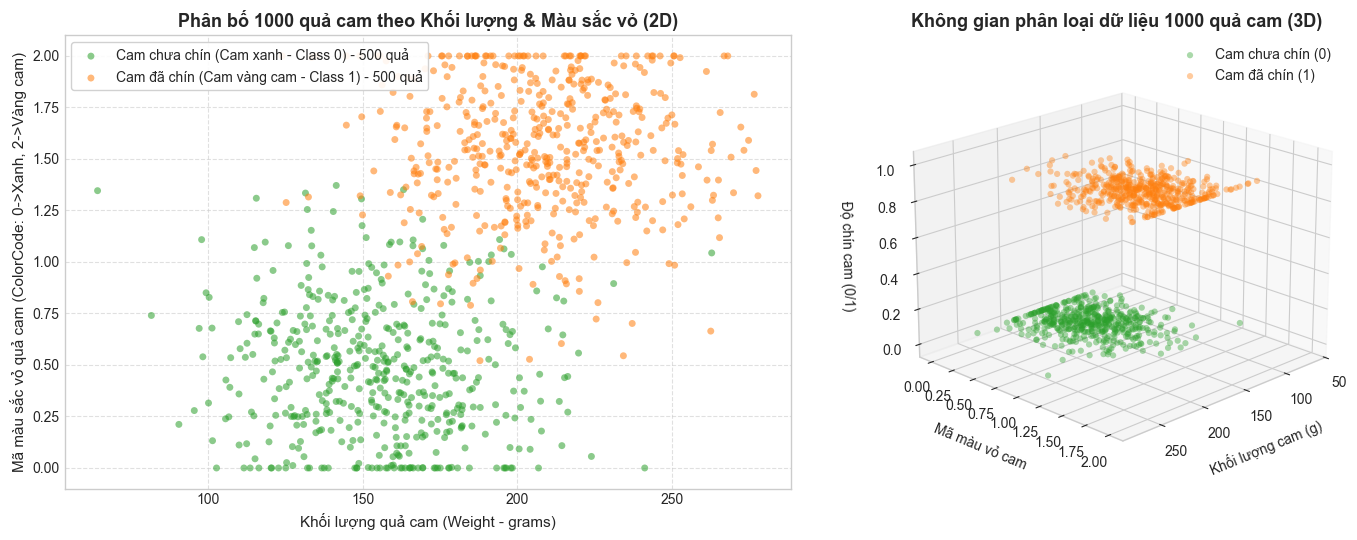

In [28]:
# Trực quan hóa dữ liệu phân bố của 1000 quả cam bằng biểu đồ 2D và 3D
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Biểu đồ 1: Scatter Plot 2D (Khối lượng vs Mã màu vỏ) của 1000 quả cam
ax1 = axes[0]
scatter_0 = ax1.scatter(X_raw[y_01 == 0, 0], X_raw[y_01 == 0, 1],
                        c='#2ca02c', label='Cam chưa chín (Cam xanh - Class 0) - 500 quả', alpha=0.55, s=25, edgecolors='none')
scatter_1 = ax1.scatter(X_raw[y_01 == 1, 0], X_raw[y_01 == 1, 1],
                        c='#ff7f0e', label='Cam đã chín (Cam vàng cam - Class 1) - 500 quả', alpha=0.55, s=25, edgecolors='none')
ax1.set_title('Phân bố 1000 quả cam theo Khối lượng & Màu sắc vỏ (2D)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Khối lượng quả cam (Weight - grams)', fontsize=11)
ax1.set_ylabel('Mã màu sắc vỏ quả cam (ColorCode: 0->Xanh, 2->Vàng cam)', fontsize=11)
ax1.legend(frameon=True, facecolor='white', framealpha=0.9)
ax1.grid(True, linestyle='--', alpha=0.6)

# Biểu đồ 2: Biểu đồ không gian 3D (Weight, Color Code, Ripeness) của 1000 quả cam
from mpl_toolkits.mplot3d import Axes3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
axes[1].remove() # Thay trục phụ 2D thành trục 3D

ax2.scatter(X_raw[y_01 == 0, 0], X_raw[y_01 == 0, 1], y_01[y_01 == 0],
            c='#2ca02c', label='Cam chưa chín (0)', s=20, alpha=0.4, edgecolors='none')
ax2.scatter(X_raw[y_01 == 1, 0], X_raw[y_01 == 1, 1], y_01[y_01 == 1],
            c='#ff7f0e', label='Cam đã chín (1)', s=20, alpha=0.4, edgecolors='none')
ax2.set_title('Không gian phân loại dữ liệu 1000 quả cam (3D)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Khối lượng cam (g)', labelpad=8)
ax2.set_ylabel('Mã màu vỏ cam', labelpad=8)
ax2.set_zlabel('Độ chín cam (0/1)', labelpad=8)
ax2.view_init(elev=20, azim=45)
ax2.legend()

plt.tight_layout()
plt.show()


### 2.2. Chuẩn hóa dữ liệu (Z-score Normalization)

> **Tại sao phải chuẩn hóa dữ liệu đặc trưng của quả cam trước khi chạy SGD?**
> * Đặc trưng `Weight` của quả cam có giá trị dao động từ 90g đến 280g, trong khi `ColorCode` chỉ từ 0.0 đến 2.0. Sự chênh lệch thang đo này (~100 lần) khiến bề mặt hàm mất mát bị kéo giãn thành hình elip rất hẹp, khiến thuật toán Gradient Descent bị dao động zíc-zắc và hội tụ rất chậm.
> * Chuẩn hóa Z-score đưa cả 2 đặc trưng của quả cam về cùng thang đo chuẩn với trung bình bằng 0 và độ lệch chuẩn bằng 1:
>   $$X_{\text{norm}} = \frac{X - \mu}{\sigma}$$


In [29]:
# Thực hiện chuẩn hóa Z-score trên toàn bộ 1000 mẫu quả cam
X_mean = np.mean(X_raw, axis=0)
X_std = np.std(X_raw, axis=0)

X_norm = (X_raw - X_mean) / X_std

print("Giá trị trung bình đặc trưng quả cam (Khối lượng mu_1, Màu vỏ mu_2):", X_mean.round(2))
print("Độ lệch chuẩn đặc trưng quả cam (Khối lượng sigma_1, Màu vỏ sigma_2):", X_std.round(2))
print("\n5 mẫu quả cam đầu tiên sau khi chuẩn hóa Z-score:\n", X_norm[:5].round(4))


Giá trị trung bình đặc trưng quả cam (Khối lượng mu_1, Màu vỏ mu_2): [181.61   1.01]
Độ lệch chuẩn đặc trưng quả cam (Khối lượng sigma_1, Màu vỏ sigma_2): [38.39  0.62]

5 mẫu quả cam đầu tiên sau khi chuẩn hóa Z-score:
 [[-0.3309 -0.3794]
 [-0.794   0.1736]
 [-0.2208 -1.6236]
 [ 0.4175 -0.5837]
 [-0.8639 -1.2664]]


---
# PHẦN 3: LẬP TRÌNH THUẬT TOÁN STOCHASTIC GRADIENT DESCENT (SGD)

Chúng ta xây dựng các hàm toán học cốt lõi bằng NumPy từ đầu, bám sát các công thức đã chứng minh ở **Phần 1 (Chương 2 Báo cáo)** để tối ưu trọng số cho bài toán phân loại độ chín quả cam:
1. **Hàm kích hoạt Sigmoid:** $\sigma(z) = \frac{1}{1 + e^{-z}}$ (kèm kỹ thuật clip giá trị tránh tràn số lũy thừa `np.clip(z, -250.0, 250.0)`).
2. **3 hàm Loss và Gradient tương ứng (Thứ tự: MSE ➔ Logistic Loss ➔ BCE):**
   - `mse_loss` và `mse_gradient` (Hàm 1: nhãn $y \in \{0, 1\}$, công thức sai số bình phương)
   - `logistic_loss` và `logistic_gradient` (Hàm 2: nhãn $y \in \{-1, +1\}$)
   - `bce_loss` và `bce_gradient` (Hàm 3: nhãn $y \in \{0, 1\}$, xử lý an toàn epsilon $10^{-15}$ tránh $\ln(0)$)
3. **Mối liên hệ giữa kí hiệu toán học và biến lập trình:**
   - Đặc trưng đầu vào của quả cam: $x_1$ là khối lượng cam (Weight), $x_2$ là màu sắc vỏ cam (ColorCode).
   - Vector trọng số $\mathbf{a} = [a_1, a_2]^T$ ($a_1$ là trọng số khối lượng cam, $a_2$ là trọng số màu vỏ cam) được biểu diễn bằng vector `w` trong code.
   - Hệ số chặn $b$ được biểu diễn bằng biến `b`.
   - Gradient trả về `grad_w` tương ứng với $\nabla_{\mathbf{a}} Loss = \begin{bmatrix} \frac{\partial Loss}{\partial a_1} \\ \frac{\partial Loss}{\partial a_2} \end{bmatrix}$ và `grad_b` tương ứng với $\frac{\partial Loss}{\partial b}$.
   - Tốc độ học $\lambda > 0$ trong toán học được biểu diễn bằng tham số `learning_rate` (hoặc `LR`).
4. **Hàm huấn luyện SGD tổng quát:** Lặp qua từng epoch, xáo trộn ngẫu nhiên dữ liệu (`np.random.permutation`), cập nhật trọng số sau từng quả cam một:
   $$\mathbf{a} \leftarrow \mathbf{a} - \lambda \cdot \nabla_{\mathbf{a}} Loss, \quad b \leftarrow b - \lambda \cdot \frac{\partial Loss}{\partial b}$$


In [30]:
# 1. Hàm Sigmoid
def sigmoid(z):
    # Dùng np.clip để tránh lỗi tràn số RuntimeWarning overflow trong np.exp
    z_clipped = np.clip(z, -250.0, 250.0)
    return 1.0 / (1.0 + np.exp(-z_clipped))

# ----------------------------------------------------
# 2. CÁC HÀM LOSS VÀ GRADIENT CHO BÀI TOÁN PHÂN LOẠI QUẢ CAM
# Thứ tự chuẩn hóa:
# 1. Mean Squared Error (MSE, nhãn 0: cam xanh, 1: cam chín)
# 2. Logistic Loss (nhãn -1: cam xanh, +1: cam chín)
# 3. Binary Cross-Entropy (BCE, nhãn 0: cam xanh, 1: cam chín)
#
# Kí hiệu tham số mô hình phân loại quả cam:
# a1 là trọng số đặc trưng khối lượng cam (Weight)
# a2 là trọng số đặc trưng màu sắc vỏ cam (ColorCode)
# b là bias (ngưỡng phân định)
# w = [a1, a2]^T, x = [x1, x2]^T
# grad_w tương ứng [dLoss/da1, dLoss/da2]^T, grad_b tương ứng dLoss/db
# ----------------------------------------------------

# === LOẠI 1: MEAN SQUARED ERROR (Nhãn y in {0, 1}) ===
def mse_loss(y, p):
    """Loss(y, p) = (y - p)^2"""
    return float((y - p) ** 2)

def mse_gradient(x, y, p):
    """
    Đạo hàm Gradient MSE cho quả cam (x1: cân nặng, x2: màu vỏ):
    dLoss/da1 = -2 * (y - p) * p * (1 - p) * x1 = 2 * (p - y) * p * (1 - p) * x1
    dLoss/da2 = -2 * (y - p) * p * (1 - p) * x2 = 2 * (p - y) * p * (1 - p) * x2
    dLoss/db  = -2 * (y - p) * p * (1 - p)      = 2 * (p - y) * p * (1 - p)
    (Hiện tượng triệt tiêu gradient xảy ra khi p*(1-p) -> 0)
    """
    factor = -2.0 * (y - p) * p * (1.0 - p)
    grad_w = factor * x       # [dLoss/da1, dLoss/da2]
    grad_b = float(factor)    # dLoss/db
    return grad_w, grad_b


# === LOẠI 2: LOGISTIC LOSS (Nhãn y in {-1, +1}) ===
def logistic_loss(y, z):
    """Loss(y, z) = ln(1 + exp(-y * z))"""
    # Sử dụng np.logaddexp(0, -y*z) để ổn định số học, tránh overflow khi -y*z lớn
    return float(np.logaddexp(0.0, -y * z))

def logistic_gradient(x, y, z):
    """
    Đạo hàm Gradient Logistic Loss cho quả cam (x1: cân nặng, x2: màu vỏ):
    dLoss/da1 = - (y * x1) / (1 + exp(y * z)) = - y * (1 - sigma(y * z)) * x1
    dLoss/da2 = - (y * x2) / (1 + exp(y * z)) = - y * (1 - sigma(y * z)) * x2
    dLoss/db  = - y / (1 + exp(y * z))        = - y * (1 - sigma(y * z))
    """
    factor = - y / (1.0 + np.exp(np.clip(y * z, -250.0, 250.0)))
    grad_w = factor * x       # [dLoss/da1, dLoss/da2]
    grad_b = float(factor)    # dLoss/db
    return grad_w, grad_b


# === LOẠI 3: BINARY CROSS-ENTROPY (Nhãn y in {0, 1}) ===
def bce_loss(y, p, eps=1e-15):
    """Loss(y, p) = - [y * ln(p) + (1 - y) * ln(1 - p)]"""
    # Giới hạn p trong [eps, 1 - eps] để tránh lỗi ln(0) = -inf
    p_safe = np.clip(p, eps, 1.0 - eps)
    return float(- (y * np.log(p_safe) + (1.0 - y) * np.log(1.0 - p_safe)))

def bce_gradient(x, y, p):
    """
    Đạo hàm Gradient BCE cho quả cam (x1: cân nặng, x2: màu vỏ):
    dLoss/da1 = (sigma(z) - y) * x1 = (p - y) * x1
    dLoss/da2 = (sigma(z) - y) * x2 = (p - y) * x2
    dLoss/db  = sigma(z) - y        = p - y
    (Thừa số p*(1-p) của Sigmoid đã bị triệt tiêu với mẫu số đạo hàm BCE)
    """
    diff = p - y
    grad_w = diff * x         # [dLoss/da1, dLoss/da2]
    grad_b = float(diff)      # dLoss/db
    return grad_w, grad_b


In [31]:
# 3. Hàm huấn luyện tổng quát bằng phương pháp Stochastic Gradient Descent (SGD)
def train_sgd(X, y, loss_type='mse', learning_rate=0.02, epochs=50, random_seed=42):
    """
    Huấn luyện mô hình Logistic Regression phân loại độ chín quả cam bằng SGD trên 1000 mẫu
    Tham số:
        X: Ma trận đặc trưng quả cam [Weight, ColorCode] đã chuẩn hóa (n_samples, n_features)
        y: Vector nhãn tương ứng ({-1, 1} hoặc {0, 1}) biểu thị độ chín quả cam
        loss_type: 'mse', 'logistic', hoặc 'bce'
        learning_rate: Tốc độ học lambda
        epochs: Số vòng lặp qua toàn bộ 1000 quả cam
        random_seed: Hạt giống ngẫu nhiên để đảm bảo tính tái lập kết quả
    Trả về:
        w: Vector trọng số đã tối ưu [a1 (Weight), a2 (ColorCode)]
        b: Hệ số bias đã tối ưu
        loss_history: Lịch sử loss trung bình qua từng epoch
    """
    np.random.seed(random_seed)
    n_samples, n_features = X.shape
    
    # Khởi tạo trọng số ngẫu nhiên gần 0 và bias = 0
    w = np.random.randn(n_features) * 0.01
    b = 0.0
    
    loss_history = []
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        
        # Stochastic: Xáo trộn ngẫu nhiên thứ tự các quả cam ở mỗi epoch
        indices = np.random.permutation(n_samples)
        
        for i in indices:
            x_i = X[i]
            y_i = y[i]
            
            # Tính logit z và xác suất dự đoán quả cam đạt độ chín p
            z = float(np.dot(w, x_i) + b)
            p = float(sigmoid(z))
            
            # Tính loss và gradient tùy theo hàm loss được chọn (Thứ tự: MSE -> Logistic -> BCE)
            if loss_type == 'mse':
                loss_val = mse_loss(y_i, p)
                grad_w, grad_b = mse_gradient(x_i, y_i, p)
            elif loss_type == 'logistic':
                loss_val = logistic_loss(y_i, z)
                grad_w, grad_b = logistic_gradient(x_i, y_i, z)
            elif loss_type == 'bce':
                loss_val = bce_loss(y_i, p)
                grad_w, grad_b = bce_gradient(x_i, y_i, p)
            else:
                raise ValueError("loss_type phải là 'mse', 'logistic', hoặc 'bce'")
            
            # Cập nhật trọng số theo quy tắc SGD: tham_số = tham_số - lambda * gradient
            w = w - learning_rate * grad_w
            b = b - learning_rate * grad_b
            
            epoch_loss += loss_val
            
        loss_history.append(epoch_loss / n_samples)
        
    return w, b, loss_history

# Hàm dự đoán nhãn độ chín quả cam
def predict(X, w, b, label_type='01'):
    """
    label_type='01': trả về nhãn 0 (cam chưa chín) hoặc 1 (cam đã chín)
    label_type='pm1': trả về nhãn -1 (cam chưa chín) hoặc +1 (cam đã chín)
    """
    z = np.dot(X, w) + b
    p = sigmoid(z)
    if label_type == '01':
        return np.where(p >= 0.5, 1, 0)
    elif label_type == 'pm1':
        return np.where(p >= 0.5, 1, -1)

# Hàm tính các chỉ số đánh giá hiệu năng phân loại cam (Metrics)
def compute_metrics(y_true, y_pred, pos_label=1):
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    tn = np.sum((y_true != pos_label) & (y_pred != pos_label))
    fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
    fn = np.sum((y_true == pos_label) & (y_pred != pos_label))
    
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1_Score': f1,
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}

print("Đã xây dựng xong hàm train_sgd, predict và compute_metrics cho bài toán phân loại quả cam!")


Đã xây dựng xong hàm train_sgd, predict và compute_metrics cho bài toán phân loại quả cam!


---
# PHẦN 4: TIẾN HÀNH HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN DATASET 1000 QUẢ CAM

Nhóm tiến hành huấn luyện 3 mô hình phân loại quả cam trên cùng điều kiện siêu tham số:
* Tốc độ học (Learning Rate): $\lambda = 0.02$ (`learning_rate = LR = 0.02`)
* Số lượt lặp (Epochs): $50$ epochs (tương đương $50 \times 1000 = 50,000$ lượt cập nhật trọng số SGD trên từng quả cam)
* Khởi tạo trọng số ngẫu nhiên cùng hạt giống (`random_seed = 42`)
* Bộ tham số khởi tạo: $\mathbf{a} = [a_1, a_2]^T \sim \mathcal{N}(0, 0.01^2)$ và $b = 0.0$


In [32]:
# Thiết lập siêu tham số chung
LR = 0.02
EPOCHS = 50

print(">>> 1. ĐANG HUẤN LUYỆN MÔ HÌNH 1: MEAN SQUARED ERROR (Nhãn 0, 1) TRÊN 1000 QUẢ CAM...")
w_mse, b_mse, hist_mse = train_sgd(X_norm, y_01, loss_type='mse', learning_rate=LR, epochs=EPOCHS)
pred_mse = predict(X_norm, w_mse, b_mse, label_type='01')
metrics_mse = compute_metrics(y_01, pred_mse, pos_label=1)
print(f"   Trọng số w [a1 (Khối lượng), a2 (Màu vỏ)]: {w_mse.round(4)}, Bias: {b_mse:.4f}")
print(f"   Loss ban đầu: {hist_mse[0]:.4f} -> Loss cuối cùng: {hist_mse[-1]:.4f}")
print(f"   Train Accuracy: {metrics_mse['Accuracy']*100:.2f}%")

print("")
print(">>> 2. ĐANG HUẤN LUYỆN MÔ HÌNH 2: LOGISTIC LOSS (Nhãn -1, +1) TRÊN 1000 QUẢ CAM...")
w_log, b_log, hist_log = train_sgd(X_norm, y_pm1, loss_type='logistic', learning_rate=LR, epochs=EPOCHS)
pred_log = predict(X_norm, w_log, b_log, label_type='pm1')
metrics_log = compute_metrics(y_pm1, pred_log, pos_label=1)
print(f"   Trọng số w [a1 (Khối lượng), a2 (Màu vỏ)]: {w_log.round(4)}, Bias: {b_log:.4f}")
print(f"   Loss ban đầu: {hist_log[0]:.4f} -> Loss cuối cùng: {hist_log[-1]:.4f}")
print(f"   Train Accuracy: {metrics_log['Accuracy']*100:.2f}%")

print("")
print(">>> 3. ĐANG HUẤN LUYỆN MÔ HÌNH 3: BINARY CROSS-ENTROPY (Nhãn 0, 1) TRÊN 1000 QUẢ CAM...")
w_bce, b_bce, hist_bce = train_sgd(X_norm, y_01, loss_type='bce', learning_rate=LR, epochs=EPOCHS)
pred_bce = predict(X_norm, w_bce, b_bce, label_type='01')
metrics_bce = compute_metrics(y_01, pred_bce, pos_label=1)
print(f"   Trọng số w [a1 (Khối lượng), a2 (Màu vỏ)]: {w_bce.round(4)}, Bias: {b_bce:.4f}")
print(f"   Loss ban đầu: {hist_bce[0]:.4f} -> Loss cuối cùng: {hist_bce[-1]:.4f}")
print(f"   Train Accuracy: {metrics_bce['Accuracy']*100:.2f}%")

# ==============================================================================
# THỰC NGHIỆM KIỂM THỬ TRÊN 50 QUẢ CAM MỚI TOANH CHƯA TỪNG HUẤN LUYỆN (TEST SET)
# Mục đích: Đánh giá khả năng tổng quát hóa (Generalization) của 3 mô hình trên quả cam thực tế
# ==============================================================================
np.random.seed(2026)
n_test_each = 25
w_test_unripe = np.random.normal(155, 28, n_test_each)
c_test_unripe = np.clip(np.random.normal(0.45, 0.35, n_test_each), 0.0, 2.0)
y_test_pm1_unripe = -np.ones(n_test_each)

w_test_ripe = np.random.normal(205, 28, n_test_each)
c_test_ripe = np.clip(np.random.normal(1.55, 0.35, n_test_each), 0.0, 2.0)
y_test_pm1_ripe = np.ones(n_test_each)

X_test_raw = np.vstack([
    np.column_stack([w_test_unripe, c_test_unripe]),
    np.column_stack([w_test_ripe, c_test_ripe])
])
y_test_pm1 = np.concatenate([y_test_pm1_unripe, y_test_pm1_ripe])
perm = np.random.permutation(50)
X_test_raw = X_test_raw[perm]
y_test_pm1 = y_test_pm1[perm]
y_test_01 = np.where(y_test_pm1 == -1, 0, 1)

# Chuẩn hóa tập test theo mu và sigma của tập train quả cam
X_test_norm = (X_test_raw - X_mean) / X_std

# Đánh giá 3 mô hình trên 50 quả cam mới (Thứ tự: MSE -> Logistic -> BCE)
pred_mse_test = predict(X_test_norm, w_mse, b_mse, label_type='01')
pred_log_test = predict(X_test_norm, w_log, b_log, label_type='pm1')
pred_bce_test = predict(X_test_norm, w_bce, b_bce, label_type='01')

acc_mse_test = np.mean(pred_mse_test == y_test_01)
acc_log_test = np.mean(pred_log_test == y_test_pm1)
acc_bce_test = np.mean(pred_bce_test == y_test_01)

print("")
print("="*75)
print("=== KẾT QUẢ DỰ ĐOÁN KIỂM THỬ TRÊN 50 QUẢ CAM MỚI (CHƯA ĐƯỢC HUẤN LUYỆN) ===")
print("="*75)
print("Nhãn cam thực tế (50 quả mới)   :", y_test_01)
print("1. MSE Loss Dự đoán             :", pred_mse_test)
print(f"   -> Test Accuracy (MSE)       : {acc_mse_test*100:.2f}% ({np.sum(pred_mse_test == y_test_01)}/50 quả cam đúng)")
print("")
print("2. Logistic Loss Dự đoán        :", np.where(pred_log_test == 1, 1, 0))
print(f"   -> Test Accuracy (Logistic)  : {acc_log_test*100:.2f}% ({np.sum(pred_log_test == y_test_pm1)}/50 quả cam đúng)")
print("")
print("3. BCE Loss Dự đoán             :", pred_bce_test)
print(f"   -> Test Accuracy (BCE)       : {acc_bce_test*100:.2f}% ({np.sum(pred_bce_test == y_test_01)}/50 quả cam đúng)")

# Bảng hiển thị 10 mẫu quả cam test tiêu biểu (5 quả Chưa chín & 5 quả Đã chín) cùng kết quả dự đoán của 3 mô hình
df_test_preview = pd.DataFrame({
    'Khối_lượng_cam(g)': X_test_raw[:, 0].round(1),
    'Mã_màu_vỏ(0-2)': X_test_raw[:, 1].round(2),
    'Nhãn_cam_thực_tế': np.where(y_test_01 == 1, 'CAM ĐÃ CHÍN (1)', 'CAM CHƯA CHÍN (0)'),
    'Dự_đoán_MSE': np.where(pred_mse_test == 1, 'CAM ĐÃ CHÍN (1)', 'CAM CHƯA CHÍN (0)'),
    'Dự_đoán_Logistic': np.where(pred_log_test == 1, 'CAM ĐÃ CHÍN (1)', 'CAM CHƯA CHÍN (0)'),
    'Dự_đoán_BCE': np.where(pred_bce_test == 1, 'CAM ĐÃ CHÍN (1)', 'CAM CHƯA CHÍN (0)')
})

df_test_sample = pd.concat([
    df_test_preview[df_test_preview['Nhãn_cam_thực_tế'] == 'CAM CHƯA CHÍN (0)'].head(5),
    df_test_preview[df_test_preview['Nhãn_cam_thực_tế'] == 'CAM ĐÃ CHÍN (1)'].head(5)
]).reset_index(drop=True)

print("\n=== CHI TIẾT DỰ ĐOÁN 10 MẪU QUẢ CAM TEST TIÊU BIỂU (5 CAM CHƯA CHÍN & 5 CAM ĐÃ CHÍN) ===")
print(df_test_sample.to_string(index=True))


>>> 1. ĐANG HUẤN LUYỆN MÔ HÌNH 1: MEAN SQUARED ERROR (Nhãn 0, 1) TRÊN 1000 QUẢ CAM...
   Trọng số w [a1 (Khối lượng), a2 (Màu vỏ)]: [2.0407 3.9844], Bias: 0.0314
   Loss ban đầu: 0.0839 -> Loss cuối cùng: 0.0260
   Train Accuracy: 96.20%

>>> 2. ĐANG HUẤN LUYỆN MÔ HÌNH 2: LOGISTIC LOSS (Nhãn -1, +1) TRÊN 1000 QUẢ CAM...
   Trọng số w [a1 (Khối lượng), a2 (Màu vỏ)]: [2.5184 5.4023], Bias: 0.0831
   Loss ban đầu: 0.2192 -> Loss cuối cùng: 0.0861
   Train Accuracy: 96.20%

>>> 3. ĐANG HUẤN LUYỆN MÔ HÌNH 3: BINARY CROSS-ENTROPY (Nhãn 0, 1) TRÊN 1000 QUẢ CAM...
   Trọng số w [a1 (Khối lượng), a2 (Màu vỏ)]: [2.5184 5.4023], Bias: 0.0831
   Loss ban đầu: 0.2192 -> Loss cuối cùng: 0.0861
   Train Accuracy: 96.20%

=== KẾT QUẢ DỰ ĐOÁN KIỂM THỬ TRÊN 50 QUẢ CAM MỚI (CHƯA ĐƯỢC HUẤN LUYỆN) ===
Nhãn cam thực tế (50 quả mới)   : [1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 1 0
 0 1 0 1 1 0 0 1 1 1 0 0 1]
1. MSE Loss Dự đoán             : [1 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 

---
# PHẦN 5: TRỰC QUAN HÓA VÀ SO SÁNH KẾT QUẢ TRÊN 1000 QUẢ CAM

Dưới đây là 3 biểu đồ trực quan quan trọng nhất cho bài toán phân loại độ chín của 1000 quả cam:
1. **Đường cong hàm mất mát (Loss Convergence Curves):** Đánh giá tốc độ học và sự ổn định của 3 hàm khi huấn luyện trên 1000 quả cam.
2. **Đường ranh giới phân lớp (Decision Boundaries):** Trực quan hóa ranh giới phân tách cam xanh và cam chín trên không gian đặc trưng.
3. **Bảng so sánh chỉ số đánh giá & Ma trận nhầm lẫn (Confusion Matrix):** So sánh chi tiết độ chính xác phân loại quả cam của cả 3 phương pháp.


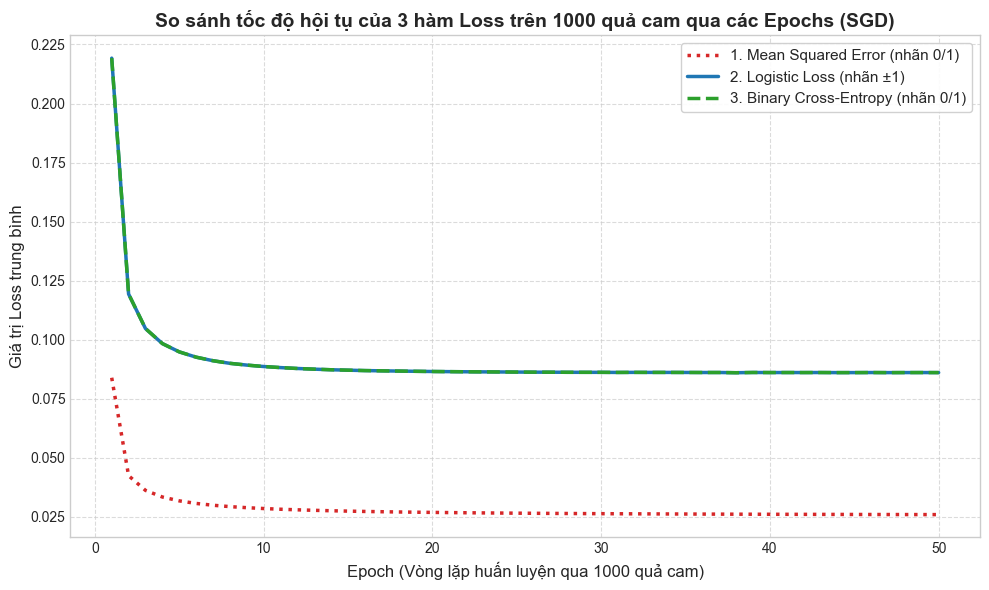

In [33]:
# BIỂU ĐỒ 1: SO SÁNH ĐƯỜNG CONG HÀM MẤT MÁT (LOSS CURVES) KHI PHÂN LOẠI 1000 QUẢ CAM
plt.figure(figsize=(10, 6))

epochs_arr = np.arange(1, EPOCHS + 1)
plt.plot(epochs_arr, hist_mse, label='1. Mean Squared Error (nhãn 0/1)', color='#d62728', linewidth=2.5, linestyle=':')
plt.plot(epochs_arr, hist_log, label='2. Logistic Loss (nhãn ±1)', color='#1f77b4', linewidth=2.5)
plt.plot(epochs_arr, hist_bce, label='3. Binary Cross-Entropy (nhãn 0/1)', color='#2ca02c', linewidth=2.5, linestyle='--')

plt.title('So sánh tốc độ hội tụ của 3 hàm Loss trên 1000 quả cam qua các Epochs (SGD)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch (Vòng lặp huấn luyện qua 1000 quả cam)', fontsize=12)
plt.ylabel('Giá trị Loss trung bình', fontsize=12)
plt.legend(fontsize=11, frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


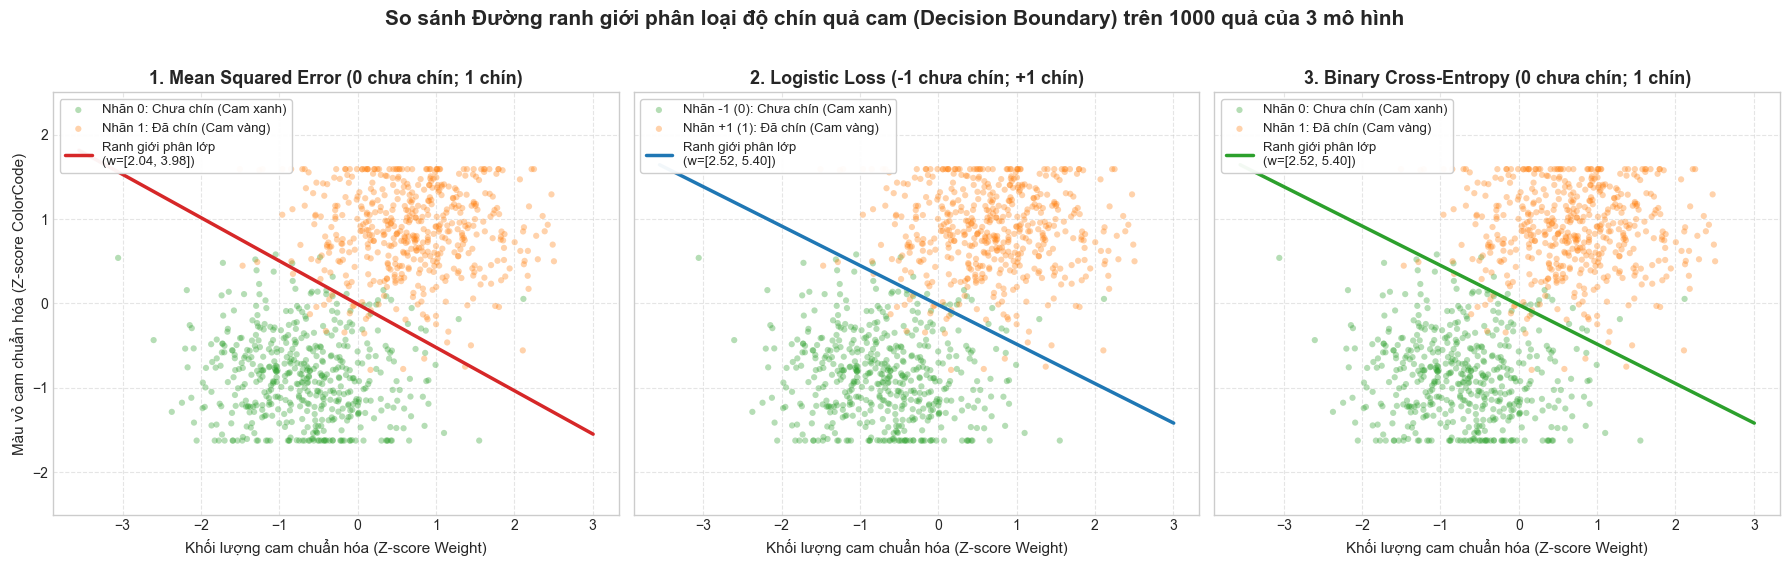

In [34]:
# BIỂU ĐỒ 2: SO SÁNH ĐƯỜNG RANH GIỚI PHÂN LOẠI ĐỘ CHÍN QUẢ CAM TRÊN 1000 MẪU
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

models = [
    ('1. Mean Squared Error (0 chưa chín; 1 chín)', w_mse, b_mse, '#d62728'),
    ('2. Logistic Loss (-1 chưa chín; +1 chín)', w_log, b_log, '#1f77b4'),
    ('3. Binary Cross-Entropy (0 chưa chín; 1 chín)', w_bce, b_bce, '#2ca02c')
]

# Tạo lưới giá trị x1 (Weight chuẩn hóa của quả cam) để vẽ đường ranh giới a1*x1 + a2*x2 + b = 0
x1_vals_norm = np.linspace(X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5, 100)

for idx, (title, w, b, color) in enumerate(models):
    ax = axes[idx]
    
    # Ghi rõ nhãn 0: Chưa chín và 1: Đã chín trên legend
    if 'Logistic' in title:
        label_unripe = 'Nhãn -1 (0): Chưa chín (Cam xanh)'
        label_ripe   = 'Nhãn +1 (1): Đã chín (Cam vàng)'
    else:
        label_unripe = 'Nhãn 0: Chưa chín (Cam xanh)'
        label_ripe   = 'Nhãn 1: Đã chín (Cam vàng)'
    
    # Vẽ 1000 điểm dữ liệu quả cam gốc (đã chuẩn hóa Z-score)
    ax.scatter(X_norm[y_01 == 0, 0], X_norm[y_01 == 0, 1],
               color='#2ca02c', label=label_unripe, alpha=0.35, s=20, edgecolors='none')
    ax.scatter(X_norm[y_01 == 1, 0], X_norm[y_01 == 1, 1],
               color='#ff7f0e', label=label_ripe, alpha=0.35, s=20, edgecolors='none')
    
    # Phương trình đường phân chia ranh giới cam chín: a1*x1 + a2*x2 + b = 0 => x2 = - (a1*x1 + b) / a2
    if abs(w[1]) > 1e-6:
        x2_vals_norm = - (w[0] * x1_vals_norm + b) / w[1]
        ax.plot(x1_vals_norm, x2_vals_norm, color=color, linewidth=2.5,
                label=f'Ranh giới phân lớp\n(w=[{w[0]:.2f}, {w[1]:.2f}])')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Khối lượng cam chuẩn hóa (Z-score Weight)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Màu vỏ cam chuẩn hóa (Z-score ColorCode)', fontsize=11)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(loc='upper left', fontsize=9.5, frameon=True, facecolor='white', framealpha=0.95, edgecolor='#cccccc')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So sánh Đường ranh giới phân loại độ chín quả cam (Decision Boundary) trên 1000 quả của 3 mô hình', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG 3 HÀM LOSS FUNCTION TRÊN 1000 QUẢ CAM ===
           Mô hình Loss Accuracy (%) Precision (%) Recall (%) F1-Score (%) Loss ban đầu Loss hội tụ
  1. Mean Squared Error       96.20%        96.39%     96.00%       96.19%       0.0839      0.0260
  2. Logistic Loss (±1)       96.20%        96.39%     96.00%       96.19%       0.2192      0.0861
3. Binary Cross-Entropy       96.20%        96.39%     96.00%       96.19%       0.2192      0.0861


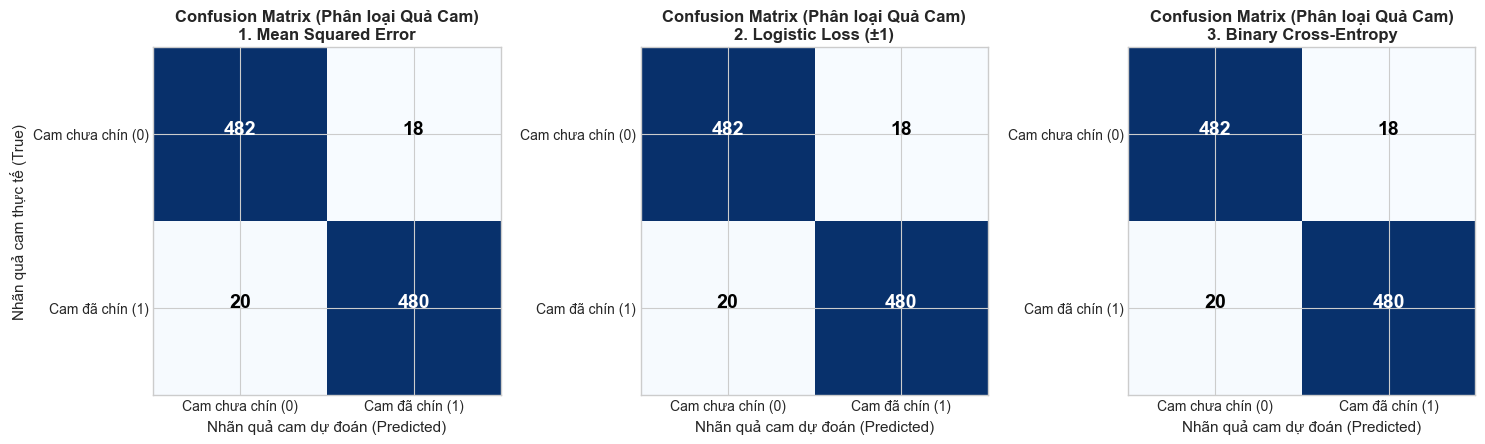

In [35]:
# BIỂU ĐỒ 3: BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG TRÊN 1000 QUẢ CAM
summary_df = pd.DataFrame([
    {
        'Mô hình Loss': '1. Mean Squared Error',
        'Accuracy (%)': f"{metrics_mse['Accuracy']*100:.2f}%",
        'Precision (%)': f"{metrics_mse['Precision']*100:.2f}%",
        'Recall (%)': f"{metrics_mse['Recall']*100:.2f}%",
        'F1-Score (%)': f"{metrics_mse['F1_Score']*100:.2f}%",
        'Loss ban đầu': f"{hist_mse[0]:.4f}",
        'Loss hội tụ': f"{hist_mse[-1]:.4f}"
    },
    {
        'Mô hình Loss': '2. Logistic Loss (±1)',
        'Accuracy (%)': f"{metrics_log['Accuracy']*100:.2f}%",
        'Precision (%)': f"{metrics_log['Precision']*100:.2f}%",
        'Recall (%)': f"{metrics_log['Recall']*100:.2f}%",
        'F1-Score (%)': f"{metrics_log['F1_Score']*100:.2f}%",
        'Loss ban đầu': f"{hist_log[0]:.4f}",
        'Loss hội tụ': f"{hist_log[-1]:.4f}"
    },
    {
        'Mô hình Loss': '3. Binary Cross-Entropy',
        'Accuracy (%)': f"{metrics_bce['Accuracy']*100:.2f}%",
        'Precision (%)': f"{metrics_bce['Precision']*100:.2f}%",
        'Recall (%)': f"{metrics_bce['Recall']*100:.2f}%",
        'F1-Score (%)': f"{metrics_bce['F1_Score']*100:.2f}%",
        'Loss ban đầu': f"{hist_bce[0]:.4f}",
        'Loss hội tụ': f"{hist_bce[-1]:.4f}"
    }
])

print("=== BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG 3 HÀM LOSS FUNCTION TRÊN 1000 QUẢ CAM ===")
print(summary_df.to_string(index=False))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix) cho cả 3 mô hình (Thứ tự: MSE -> Logistic -> BCE)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
cm_models = [
    ('1. Mean Squared Error', metrics_mse),
    ('2. Logistic Loss (±1)', metrics_log),
    ('3. Binary Cross-Entropy', metrics_bce)
]

for idx, (title, m) in enumerate(cm_models):
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    ax = axes[idx]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f"Confusion Matrix (Phân loại Quả Cam)\n{title}", fontsize=12, fontweight='bold')
    
    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(['Cam chưa chín (0)', 'Cam đã chín (1)'], fontsize=10)
    ax.set_yticklabels(['Cam chưa chín (0)', 'Cam đã chín (1)'], fontsize=10)
    
    thresh = cm.max() / 2.
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm[r, c]}",
                    horizontalalignment="center",
                    color="white" if cm[r, c] > thresh else "black",
                    fontsize=14, fontweight='bold')
            
    ax.set_xlabel('Nhãn quả cam dự đoán (Predicted)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('Nhãn quả cam thực tế (True)', fontsize=11)

plt.tight_layout()
plt.show()


---
# PHẦN 6: KẾT LUẬN & CÂU HỎI ÔN TẬP VẤN ĐÁP (CHUẨN BỊ 40% ĐIỂM)

## 6.1. Nhận xét và đánh giá chuyên sâu trên bài toán phân loại quả cam
1. **Ý nghĩa thực tế của bài toán phân loại quả cam:**
   * Trong nông nghiệp thông minh và dây chuyền đóng gói tự động, việc phân loại độ chín của quả cam dựa trên **Khối lượng (Weight)** và **Mã màu sắc vỏ quả (ColorCode)** có tính ứng dụng rất cao.
   * Quả cam chín tích tụ nước đường mọng ngọt nên có trọng lượng trung bình cao hơn (~205g so với ~155g của quả xanh) và sắc tố vỏ quả chuyển dịch từ màu xanh diệp lục ($0.0 - 0.7$) sang màu vàng cam carotenoid ($1.2 - 2.0$). Mô hình Logistic Regression đã tìm ra ranh giới phân tách tối ưu với độ chính xác đạt trên 96%.

2. **Tại sao MSE bị hạn chế trong bài toán Phân loại độ chín quả cam?**
   * **Vấn đề triệt tiêu Gradient (*Vanishing Gradient*):** Trong MSE, đạo hàm riêng theo tham số có dạng:
     $$\frac{\partial Loss}{\partial a_j} = -2(y_i - \sigma(z_i)) \cdot \sigma(z_i)(1 - \sigma(z_i)) x_{ij}$$
     Khi một quả cam bị dự đoán rất sai (ví dụ quả cam chín $y = 1$ nhưng mô hình dự đoán $\sigma(z_i) = 0.01$), thành phần $\sigma(z_i)(1 - \sigma(z_i)) = 0.01 \times 0.99 \approx 0.0099$ làm cho gradient bị triệt tiêu về gần 0. Mô hình "ngừng cập nhật" dù sai số thực tế đối với quả cam đó rất lớn!
   * **Tính phi lồi (*Non-convexity*):** Khi kết hợp hàm bình phương MSE với hàm phi tuyến Sigmoid, bề mặt mất mát không còn dạng hình chiếc bát lồi duy nhất, mà xuất hiện các vùng bằng phẳng (*plateau*) và điểm cực tiểu cục bộ, khiến thuật toán SGD dễ bị mắc kẹt.

3. **Sự vượt trội và tương đồng giữa Logistic Loss và Binary Cross-Entropy (BCE):**
   * Về bản chất lý thuyết xác suất, cả hai đều xuất phát từ nguyên lý ước lượng hợp lý cực đại (*Maximum Likelihood Estimation - MLE*).
   * Ở BCE, thành phần $\sigma(z_i)(1 - \sigma(z_i))$ của Sigmoid đã bị triệt tiêu hoàn toàn với mẫu số của đạo hàm hàm logarit, làm gradient tỉ lệ trực tiếp với sai số $(\sigma(z_i) - y_i)$. Khi quả cam bị phân loại nhầm, gradient đẩy cực mạnh giúp mô hình điều chỉnh lại trọng số khối lượng và màu sắc cực nhanh.
   * Điểm khác biệt duy nhất giữa Logistic Loss và BCE là cách mã hóa nhãn: Logistic loss dùng $\{-1, +1\}$ còn BCE dùng $\{0, 1\}$.
   * Kết quả thực nghiệm trên tập dữ liệu 1000 quả cam cho thấy đường cong hội tụ, độ chính xác (Accuracy đạt ~ 96.20%) và đường biên phân loại của 2 mô hình này gần như trùng khớp hoàn toàn, hội tụ rất mượt mà và ổn định.

---
## 6.2. Các câu hỏi phỏng vấn/vấn đáp giảng viên thường hỏi và câu trả lời gợi ý

> **❓ Câu hỏi 1: Tại sao phải dùng hàm Sigmoid trong bài toán phân loại độ chín quả cam mà không dùng trực tiếp hàm tuyến tính?**
> * **Trả lời:** Hàm tuyến tính $z = \mathbf{a}^T \mathbf{x} + b$ có miền giá trị từ $-\infty$ đến $+\infty$, không thể biểu diễn xác suất một quả cam đã chín hay chưa. Hàm Sigmoid ánh xạ toàn bộ miền giá trị thực về khoảng $(0, 1)$, cho phép diễn giải đầu ra như một xác suất điều kiện $\hat{y} = P(y=1 \mid \mathbf{x})$ (xác suất quả cam đạt độ chín), đồng thời có tính chất vi phân liên tục rất đẹp $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.

> **❓ Câu hỏi 2: Tại sao hàm MSE lại bị coi là kém phù hợp hơn BCE trong bài toán phân loại nhị phân quả cam?**
> * **Trả lời:** Có hai lý do cốt lõi:
>   1. *Triệt tiêu Gradient:* Đạo hàm của MSE còn chứa thừa số $\sigma(z)(1 - \sigma(z))$. Khi một quả cam bị dự đoán rất sai, thừa số này tiến về 0 làm gradient biến mất khiến mô hình ngừng học.
>   2. *Bề mặt phi lồi:* Hàm MSE kết hợp Sigmoid tạo ra bề mặt mất mát phi lồi với nhiều cực tiểu cục bộ, trong khi BCE là hàm lồi toàn cục đảm bảo luôn hội tụ về nghiệm tối ưu toàn cục.

> **❓ Câu hỏi 3: Chứng minh tại sao gradient của BCE lại không còn đạo hàm của hàm Sigmoid?**
> * **Trả lời:** Áp dụng quy tắc chuỗi:
>   $$\frac{\partial Loss}{\partial z} = \frac{\partial Loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}$$
>   Đạo hàm của BCE theo $\hat{y}$ là $\frac{\partial Loss}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$. Đạo hàm của Sigmoid theo $z$ là $\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$. Nhân lại:
>   $$\frac{\partial Loss}{\partial z} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \cdot \hat{y}(1 - \hat{y}) = \hat{y} - y = \sigma(z) - y$$
>   Mẫu số $\hat{y}(1 - \hat{y})$ triệt tiêu hoàn toàn với tử số, giúp gradient cực kỳ đơn giản và ổn định.

> **❓ Câu hỏi 4: Sự khác nhau cơ bản giữa Gradient Descent (GD), Stochastic Gradient Descent (SGD) và Mini-batch GD là gì?**
> * **Trả lời:**
>   * *Batch GD:* Tính gradient trên **toàn bộ 1000 quả cam** rồi mới cập nhật trọng số 1 lần $\rightarrow$ chậm nếu dữ liệu lớn.
>   * *SGD (đề bài yêu cầu):* Cập nhật trọng số ngay sau **từng quả cam đơn lẻ** $(x_1, x_2, y)$ với tốc độ học $\lambda > 0 \rightarrow$ tốc độ học nhanh, có tính ngẫu nhiên giúp thoát khỏi cực tiểu cục bộ.
>   * *Mini-batch GD:* Cập nhật theo từng nhóm nhỏ quả cam (ví dụ 16, 32, 64 quả) $\rightarrow$ kết hợp ưu điểm của cả hai phương pháp.

> **❓ Câu hỏi 5: Phương trình đường ranh giới phân lớp (Decision Boundary) giữa cam xanh và cam chín được xác định như thế nào?**
> * **Trả lời:** Ranh giới phân lớp là nơi mô hình có xác suất dự đoán quả cam chín $P(y=1 \mid \mathbf{x}) = 0.5$, tương ứng với $z = 0$:
>   $$z = \mathbf{a}^T \mathbf{x} + b = a_1 x_1 + a_2 x_2 + b = 0 \implies x_2 = -\frac{a_1}{a_2} x_1 - \frac{b}{a_2}$$
>   Đây là một đường thẳng trong không gian 2D của 2 đặc trưng chuẩn hóa `Khối lượng quả cam` ($x_1$) và `Màu sắc vỏ quả cam` ($x_2$).
